In [1]:
import glob
from scipy.signal import savgol_filter
from dff import *

In [2]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [3]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

In [4]:
traces = get_valid_corrected_f(dirs[0])

In [5]:
[t.shape for t in traces]

[(56, 48374),
 (46, 48374),
 (73, 48374),
 (73, 48374),
 (62, 48374),
 (56, 48374),
 (41, 48374),
 (49, 48374),
 (59, 48403),
 (46, 48403),
 (71, 48403),
 (75, 48403),
 (65, 48403),
 (57, 48403),
 (39, 48403),
 (53, 48403),
 (57, 48427),
 (48, 48427),
 (67, 48427),
 (73, 48427),
 (65, 48427),
 (61, 48427),
 (41, 48427),
 (48, 48427),
 (55, 48390),
 (46, 48390),
 (65, 48390),
 (76, 48390),
 (63, 48390),
 (56, 48390),
 (40, 48390),
 (48, 48390),
 (60, 48373),
 (42, 48373),
 (65, 48373),
 (76, 48373),
 (66, 48373),
 (58, 48373),
 (40, 48373),
 (52, 48373),
 (58, 48366),
 (44, 48366),
 (66, 48366),
 (75, 48366),
 (61, 48366),
 (54, 48366),
 (42, 48366),
 (51, 48366)]

In [6]:
dff_traces, baseline, noise = dff.dff(traces[0])

In [7]:
def plot_traces(traces, F0s=None):
    N, T = traces.shape
    fix, ax = plt.subplots(N, 1, figsize=(15, N), sharex=True)
    for i, (a, t) in enumerate(zip(ax, traces)):
        a.plot(t, lw=.5, label=f"{i}")
        if F0s is not None:
            a.plot(F0s[i])
        a.legend(loc=1)
        a.set_xlim(0, len(t))

In [8]:
%matplotlib inline

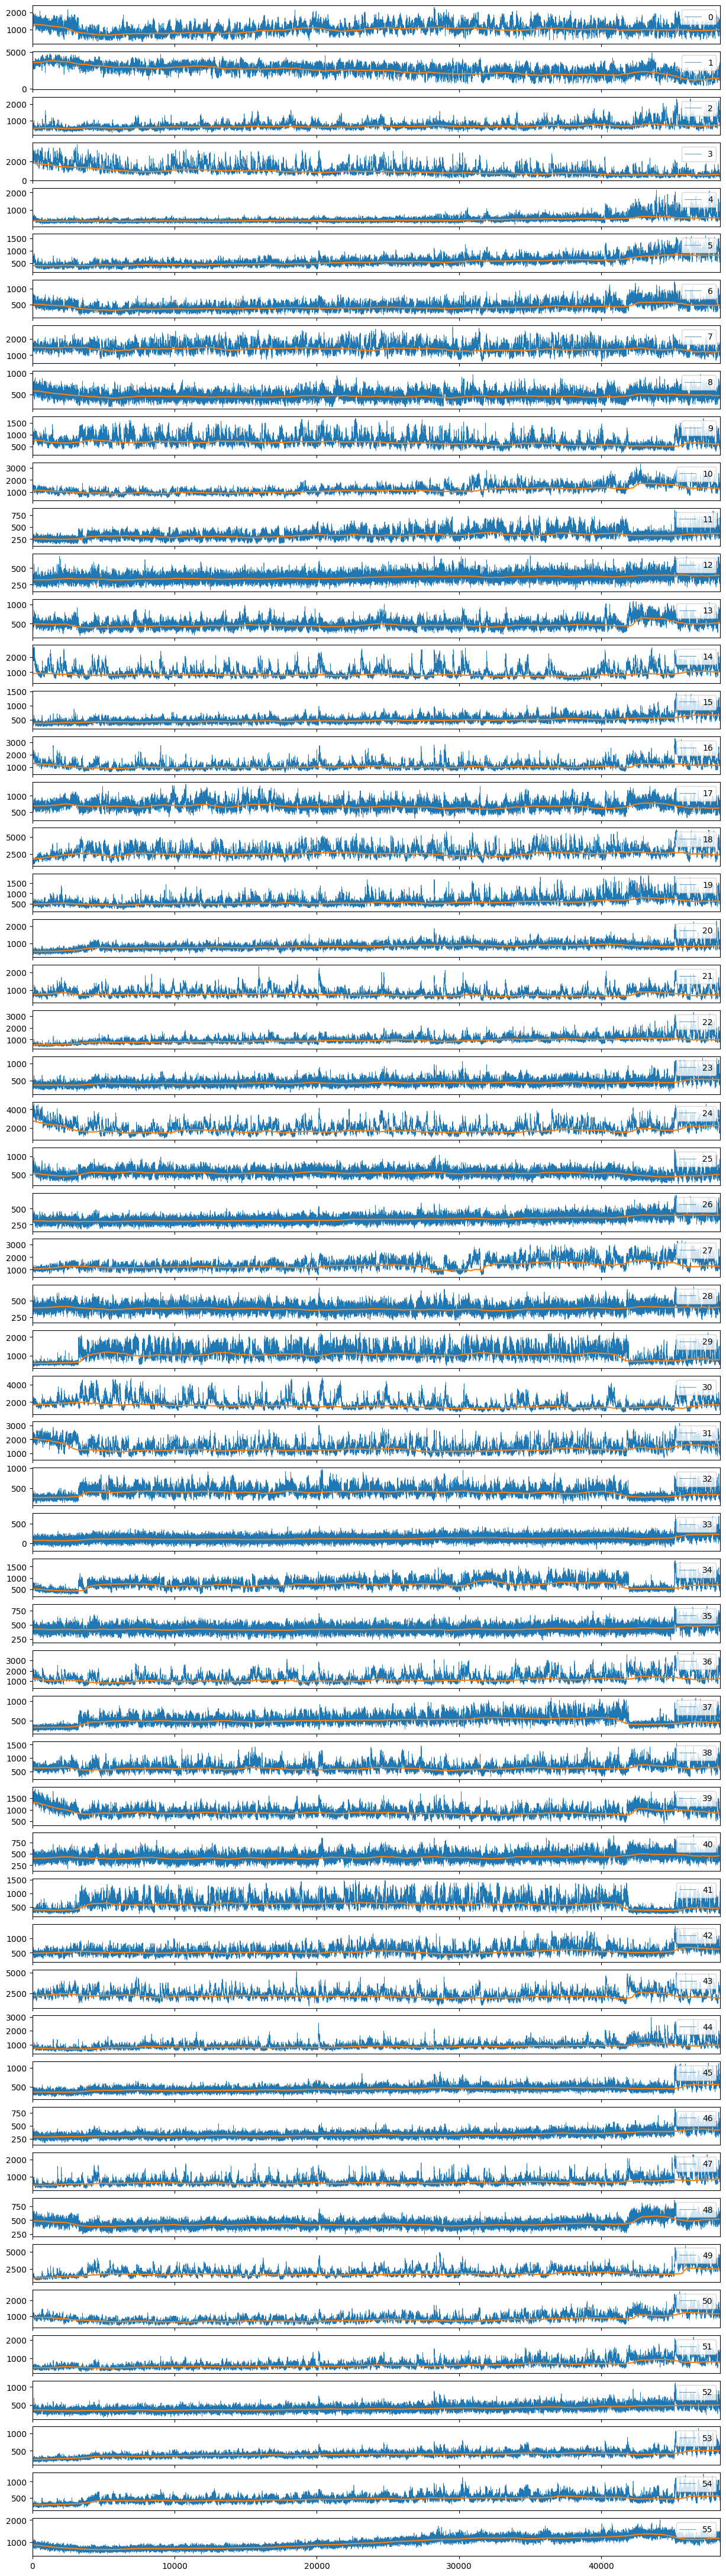

In [9]:
plot_traces(traces[0], baseline)

In [28]:
%%time
# Smooth signal using window of 51 points and 3rd-order polynomial
smoothed = savgol_filter(traces[0][0], window_length=10001, polyorder=3)

CPU times: user 1.13 s, sys: 0 ns, total: 1.13 s
Wall time: 381 ms


In [36]:
%%time
# Smooth signal using window of 51 points and 3rd-order polynomial
smoothed2 = savgol_filter(traces[0][0][:10001], window_length=10001, polyorder=3)

CPU times: user 1.14 s, sys: 558 µs, total: 1.14 s
Wall time: 254 ms


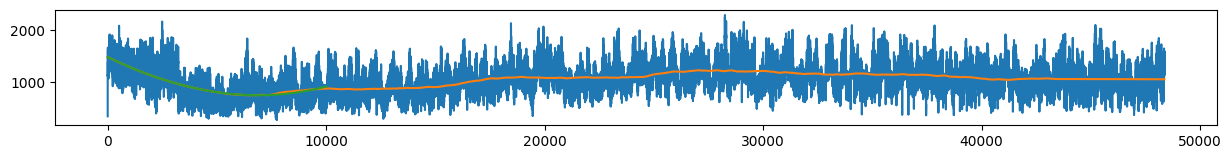

In [37]:
plt.figure(figsize=(15, 1.5))
plt.plot(traces[0][0])
plt.plot(smoothed)
plt.plot(smoothed2)

In [85]:
# %%time
from scipy.signal import savgol_coeffs

# Get the polynomial coefficients for the filter
edge_length = 10001
size = 20000
coeffs = savgol_coeffs(window_length=edge_length, polyorder=3, deriv=0)

# Manually fit polynomial to edge points
# Left edge
x_left = np.arange(edge_length)
p_left = np.polyfit(x_left, traces[0][0][:edge_length], deg=3)
pad_left = np.polyval(p_left, np.arange(-size//2, 0))

# Right edge  
x_right = np.arange(edge_length)
p_right = np.polyfit(x_right, traces[0][0][-edge_length:], deg=3)
pad_right = np.polyval(p_right, np.arange(edge_length, edge_length + size//2))

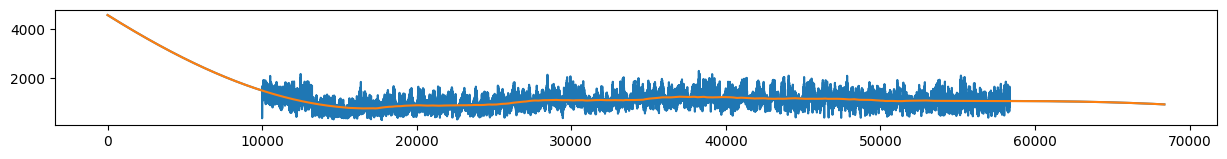

In [86]:
plt.figure(figsize=(15, 1.5))
plt.plot(np.concatenate([pad_left, traces[0][0], pad_right]));
plt.plot(np.concatenate([pad_left, smoothed, pad_right]));

In [102]:
def extrapolate_trace(trace, edge_length, size, deg=2):
    """Extrapolate trace edges using polynomial fitting.
    
    Parameters
    ----------
    trace : ndarray
        Input 1D trace (may contain NaN values)
    edge_length : int
        Number of points at each edge to fit polynomial to
    size : int
        Total padding size (will pad size//2 on each side)
    deg : int
        Degree of polynomial for fitting (default 2)
        
    Returns
    -------
    ndarray
        Padded trace with extrapolated edges
    """
    # Ensure edge_length doesn't exceed trace length
    edge_length = min(edge_length, len(trace))
    
    # Left edge: fit to non-NaN values only
    left_data = trace[:edge_length]
    left_valid = ~np.isnan(left_data)
    if left_valid.sum() > deg:  # Need more points than polynomial degree
        x_left = np.arange(edge_length)[left_valid]
        y_left = left_data[left_valid]
        p_left = np.polyfit(x_left, y_left, deg=deg)
        pad_left = np.polyval(p_left, np.arange(-size//2, 0))
    else:
        # Fallback: use first non-NaN value
        pad_left = np.full(size//2, np.nanmean(left_data))
    
    # Right edge: fit to non-NaN values only
    right_data = trace[-edge_length:]
    right_valid = ~np.isnan(right_data)
    if right_valid.sum() > deg:
        x_right = np.arange(edge_length)[right_valid]
        y_right = right_data[right_valid]
        p_right = np.polyfit(x_right, y_right, deg=deg)
        pad_right = np.polyval(p_right, np.arange(edge_length, edge_length + size//2))
    else:
        # Fallback: use last non-NaN value
        pad_right = np.full(size//2, np.nanmean(right_data))
    
    return np.concatenate([pad_left, trace, pad_right])

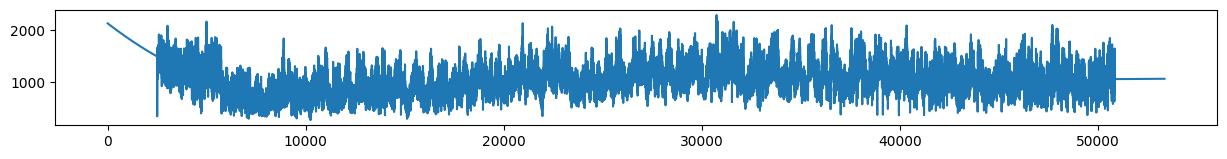

In [104]:
plt.figure(figsize=(15, 1.5))
plt.plot(extrapolate_trace(traces[0][0], 10001, 5000));

In [112]:
from typing import Tuple, Optional

In [133]:
def _dff_single_trace(
    F: np.ndarray,
    noise_method: Union[str, float],
    long_filter_length: float,
    short_filter_length: float,
    inactive_percentile: int,
    extrapolate_deg: Optional[int] = 2,
    edge_length: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Compute the "delta F over F" from the fluorescence trace.
    Uses configurable length median filters to compute baseline for
    baseline-subtraction and short timescale detrending.
    Returns the artifact-corrected and detrended dF/F, along with
    additional metadata for QA: the estimated baseline and
    the standard deviation of the noise.

    Parameters
    ----------
    F: np.ndarray
        1d numpy array of the neuropil-corrected fluorescence trace.
    noise_method: Union[str, float]
        Method for computing the noise, see ..signal_utils.noise_std.
        Choices: 'mad', 'fft', 'welch'
    long_filter_length: int
        Length of the percentile filter used to compute a rolling baseline.
    short_filter_length: int
        Length of the median filter to compute the rolling median-filtered
        signal, which is subtracted from the input `F` for noise_method='mad'.
    inactive_percentile: int
        Percentile value that defines the inactive frames used for
        calculating the baseline.
    extrapolate_deg: int
        Degree of polynomial for edge extrapolation. Default is 2.
        If 0 or None then no interpolation is performed.
    edge_length: int
        Number of points at each edge to fit polynomial to.
        Defaults to long_filter_length if set to None.

    Returns
    -------
    dF/F: ndarray
        Baseline-corrected fluorescence dF/F.
    F0: ndarray
        Estimated baseline.
    noise_sd: float
        The estimated standard deviation of the noise in the input trace.
    """
    invalid = np.isnan(F).all()
    if invalid:
        return F, F, np.nan
    
    if isinstance(noise_method, str):
        noise_sd = noise_std(
            F, noise_method, filter_length=short_filter_length, device="cpu"
        )
    else:
        noise_sd = noise_method
    
    # Optionally extrapolate trace for filtering
    if extrapolate_deg:
        if edge_length is None:
            edge_length = long_filter_length
        F_padded = extrapolate_trace(
            F, 
            edge_length=edge_length, 
            size=long_filter_length,
            deg=extrapolate_deg
        )
        pad_size = long_filter_length // 2
    else:
        F_padded = F
        pad_size = 0
    
    # Create trace using inactive frames only, by replacing outliers with nan
    low_baseline = percentile_filter(
        F_padded, 
        inactive_percentile, 
        long_filter_length
    )
    
    # If extrapolated, trim back to original length
    if extrapolate_deg:
        low_baseline = low_baseline[pad_size:-pad_size]
    
    inactive_trace = F.copy()
    active_mask = F > (low_baseline + 3 * noise_sd)
    negative_mask = F < (low_baseline - 3 * noise_sd)
    inactive_trace[active_mask + negative_mask] = np.nan
    
    # Apply extrapolation for baseline filtering as well
    if extrapolate_deg:
        inactive_trace_padded = extrapolate_trace(
            inactive_trace,
            edge_length=edge_length,
            size=long_filter_length,
            deg=extrapolate_deg
        )
        baseline = nanmedian_filter(inactive_trace_padded, long_filter_length)
        baseline = baseline[pad_size:-pad_size]
    else:
        baseline = nanmedian_filter(inactive_trace, long_filter_length)
    
    # Calculate dF/F
    dff = (F - baseline) / np.maximum(baseline, noise_sd)
    return dff, baseline, noise_sd, F_padded, pad_size, active_mask

In [134]:
from aind_ophys_utils.signal_utils import (
    nanmedian_filter,
    noise_std,
    percentile_filter,
)

In [135]:
baseline_old = _dff_single_trace(traces[0][0], "mad", 1800, 100, 10, extrapolate_deg=0)[1]
dff, baseline, noise_sd, F_padded, pad_size, active_mask = _dff_single_trace(traces[0][0], "mad", 1800, 100, 10)

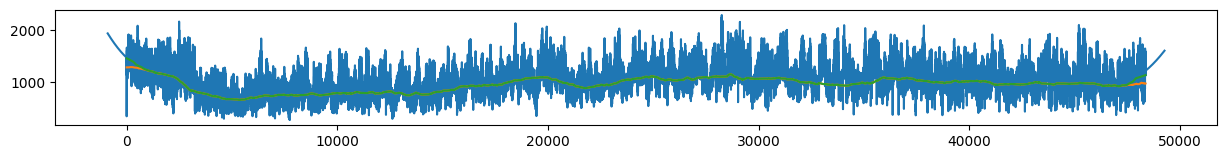

In [136]:
plt.figure(figsize=(15, 1.5))
plt.plot(np.arange(len(F_padded)) - pad_size, F_padded)
plt.plot(baseline_old)
plt.plot(baseline)

In [ ]:

    F: np.ndarray,
    noise_method: Union[str, float],
    long_filter_length: float,
    short_filter_length: float,
    inactive_percentile: int,
    extrapolate_deg: Optional[int] = 2,
    edge_length: Optional[int] = None,